# README – Transfer Learning with TensorFlow (Part 3: Scaling Up)

## Notebook Purpose

This notebook scales transfer learning to a much larger image classification task by moving from 10 food classes to 101 classes. The goal was to test whether the same transfer learning workflow could still perform well on a more complex dataset with many more categories and a much harder classification setting.

## Data and Setup

- Used the `101_food_classes_10_percent` dataset with separate training and test directories.
- Worked with 101 classes, using 10% of the training images and the full test split.
- Built TensorFlow input pipelines for loading, batching, and preprocessing images efficiently.
- Reused helper functions for directory inspection, TensorBoard logging, plotting, and history comparison.

## Model and Scaling Strategy

- Used `EfficientNetB0` as the transfer learning backbone for large-scale multi-class classification.
- Replaced the final layer with a custom classifier head for 101 output classes.
- Kept most of the pre-trained backbone frozen so the model could act as a feature extractor while training only a small number of task-specific parameters.
- This setup allowed scaling to a larger dataset without the cost of training a deep vision model from scratch.

## Training, Tracking, and Evaluation

- Compiled the model with categorical crossentropy, Adam, and accuracy.
- Trained the model for 5 epochs on the 101-class dataset and validated during training.
- Reached roughly 54% validation accuracy during training and about 58.5% test accuracy after full evaluation.
- Used checkpoints to save the best-performing weights and tracked learning behavior across epochs.

## Key Takeaways

- Practiced how to scale transfer learning from a small multi-class problem to a significantly larger one.
- Confirmed that a pre-trained EfficientNet backbone remains a strong baseline even when the number of classes increases substantially.
- Reinforced the value of transfer learning for reducing training cost while still achieving useful performance on challenging image classification tasks.

In [2]:
#import helper function
from pathlib import Path
import os

file_path = Path("helper_functions.py")
url = "https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py"

if not file_path.exists():
    !wget -O helper_functions.py {url}
else:
    print("helper_functions.py already exists, skipping download.")


# Import series of helper functions for the notebook (we've created/used these in previous notebooks)
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir

helper_functions.py already exists, skipping download.


In [3]:
#Downloading and preprocessing the data

from pathlib import Path

zip_path = Path("101_food_classes_10_percent.zip")
data_dir = Path("101_food_classes_10_percent")

# Download only if the zip file doesn't already exist
if not zip_path.exists():
    !wget -O {zip_path} https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
else:
    print(f"{zip_path} already exists, skipping download.")

# Unzip only if the extracted folder doesn't already exist
if not data_dir.exists():
    unzip_data(zip_path)
else:
    print(f"{data_dir} already exists, skipping unzip.")

# Setup data directories
train_dir = data_dir / "train"
test_dir = data_dir / "test"

--2026-04-23 12:32:59--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.170.207, 172.217.208.207, 74.125.29.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.170.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G  40.1MB/s    in 46s     

2026-04-23 12:33:46 (33.7 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [4]:

# How many images/classes are there?
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/test'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/foie_gras'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/club_sandwich'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/cheese_plate'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/cup_cakes'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/garlic_bread'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/gnocchi'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/ice_cream'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/samosa'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/donuts'.
There are 0 directories and 250 images in '101_food_class

## Train a big dog model with transfer learning on 10% of 101 food classes

In [5]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224, 224)

train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)
                                                                                
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                shuffle=False) # don't shuffle test data for prediction analysis

Found 7575 files belonging to 101 classes.


W0000 00:00:1776940535.375792 1963372 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 25250 files belonging to 101 classes.


In [7]:
# Create checkpoint callback to save model for later use
checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True, # save only the model weights
                                                         monitor="val_accuracy", # save the model weights which score the best validation accuracy
                                                         save_best_only=True) # only keep the best model weights on file (delete the rest)

In [8]:
# Import the required modules for model creation
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

## NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetB0
], name ="data_augmentation")

In [9]:

# Setup base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name="input_layer") # shape of input image
x = data_augmentation(inputs) # augment images (only happens during training)
x = base_model(x, training=False) # put the base model in inference mode so we can use it to extract features without updating the weights
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x) # pool the outputs of the base model
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax", name="output_layer")(x) # same number of outputs as classes
model = tf.keras.Model(inputs, outputs)

In [10]:

# Get a summary of our model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(), # use Adam with default settings
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs=5, # fit for 5 epochs to keep experiments quick
                                           validation_data=test_data,
                                           validation_steps=int(0.15 * len(test_data)), # evaluate on smaller portion of test data
                                           callbacks=[checkpoint_callback]) # save best model weights to file
     

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 73s 296ms/step - accuracy: 0.2660 - loss: 3.4101 - val_accuracy: 0.4457 - val_loss: 2.5488
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 71s 298ms/step - accuracy: 0.4867 - loss: 2.2661 - val_accuracy: 0.5162 - val_loss: 2.0275
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 70s 295ms/step - accuracy: 0.5485 - loss: 1.8970 - val_accuracy: 0.5244 - val_loss: 1.9166
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 70s 296ms/step - accuracy: 0.5864 - loss: 1.6822 - val_accuracy: 0.5328 - val_loss: 1.8245
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 68s 288ms/step - accuracy: 0.6193 - loss: 1.5426 - val_accuracy: 0.5400 - val_loss: 1.7833


In [12]:
# Evaluate model 
results_feature_extraction_model = model.evaluate(test_data)
results_feature_extraction_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 136s 172ms/step - accuracy: 0.5855 - loss: 1.5811


[1.5810664892196655, 0.5855445265769958]

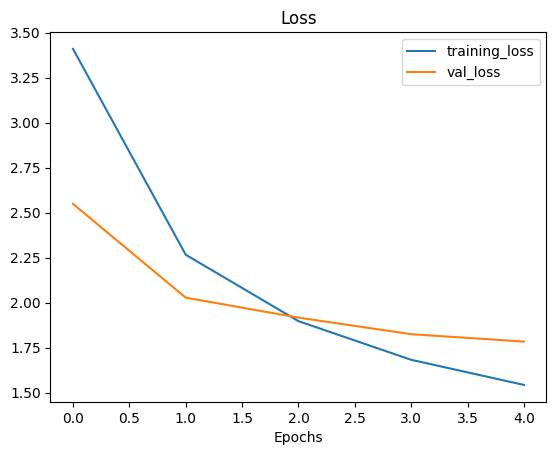

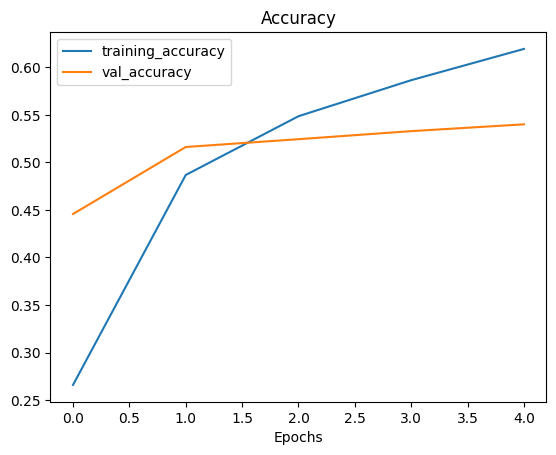

In [ ]:
# plot_loss_curves(history_all_classes_10_percent)

## Fine-tuning

In [14]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze every layer except for the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [15]:
# Recompile model with lower learning rate
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4), # 10x lower learning rate than default
              metrics=['accuracy'])

In [16]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetb0 True
global_average_pooling True
output_layer True


In [ ]:
# # Check which layers are trainable
# for layer_number, layer in enumerate(base_model.layers):
#   print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [18]:

# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs, this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)), # validate on 15% of the test data
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1]) # start from previous last epoch

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.6405 - loss: 1.4711 - val_accuracy: 0.5583 - val_loss: 1.7002
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 72s 302ms/step - accuracy: 0.6767 - loss: 1.3115 - val_accuracy: 0.5673 - val_loss: 1.6582
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 72s 302ms/step - accuracy: 0.6995 - loss: 1.2290 - val_accuracy: 0.5736 - val_loss: 1.6162
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 73s 310ms/step - accuracy: 0.7084 - loss: 1.1720 - val_accuracy: 0.5834 - val_loss: 1.5708
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 71s 300ms/step - accuracy: 0.7282 - loss: 1.1159 - val_accuracy: 0.5898 - val_loss: 1.5496
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 73s 308ms/step - accuracy: 0.7358 - loss: 1.0605 - val_accuracy: 0.5810 - val_loss: 1.5748


In [19]:
# Evaluate fine-tuned model on the whole test dataset
results_all_classes_10_percent_fine_tune = model.evaluate(test_data)
results_all_classes_10_percent_fine_tune

790/790 ━━━━━━━━━━━━━━━━━━━━ 146s 185ms/step - accuracy: 0.6212 - loss: 1.4133


[1.4133448600769043, 0.6212277412414551]

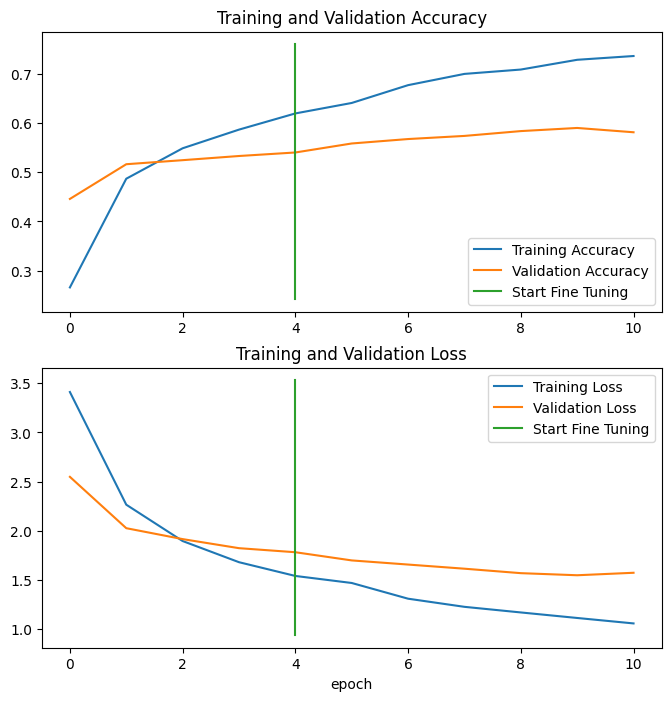

In [ ]:
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

In [24]:
# # Save model to drive so it can be used later 
model.save("drive/My Drive/tensorflow_course/101_food_class_10_percent_saved_big_dog_model.weights.keras")

## Evaluating the performance of the big dog model across all different classes

In [27]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras

# Paths
zip_path = Path("06_101_food_class_10_percent_saved_big_dog_model.zip")
model_dir = Path("06_101_food_class_10_percent_saved_big_dog_model")

# Download only if the zip file doesn't already exist
if not zip_path.exists():
    !wget -O {zip_path} https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
else:
    print(f"{zip_path} already exists, skipping download.")

# Unzip only if the model directory doesn't already exist
if not model_dir.exists():
    unzip_data(zip_path)
else:
    print(f"{model_dir} already exists, skipping unzip.")

06_101_food_class_10_percent_saved_big_dog_model.zip already exists, skipping download.
06_101_food_class_10_percent_saved_big_dog_model already exists, skipping unzip.


In [28]:

# Check to see if loaded model is a trained model
loaded_loss, loaded_accuracy = model.evaluate(test_data)
loaded_loss, loaded_accuracy

790/790 ━━━━━━━━━━━━━━━━━━━━ 141s 178ms/step - accuracy: 0.6212 - loss: 1.4133


(1.4133448600769043, 0.6212277412414551)

In [29]:
# Make predictions with model
pred_probs = model.predict(test_data, verbose=1) # set verbosity to see how long it will take 

790/790 ━━━━━━━━━━━━━━━━━━━━ 139s 174ms/step


In [30]:

# How many predictions are there?
len(pred_probs)

25250

In [31]:

# What's the shape of our predictions?
pred_probs.shape

(25250, 101)

In [32]:
# How do they look?
pred_probs[:10]

array([[3.69123071e-01, 3.11628333e-04, 1.68557689e-01, ...,
        4.35408001e-05, 7.14570098e-03, 1.40760746e-02],
       [8.08806777e-01, 7.71239684e-07, 5.11620985e-03, ...,
        3.45099065e-03, 2.96826715e-06, 3.10082032e-05],
       [3.85174990e-01, 7.32496753e-03, 2.62466408e-02, ...,
        9.76741081e-04, 1.27622439e-03, 4.37060650e-03],
       ...,
       [3.35600883e-01, 1.66336758e-05, 4.75825509e-03, ...,
        4.82224710e-02, 4.94535198e-04, 7.67766207e-04],
       [1.51504457e-01, 4.83039301e-04, 3.69001925e-01, ...,
        6.90461718e-04, 1.52737703e-04, 2.12589366e-04],
       [5.57728767e-01, 4.40867643e-06, 3.49105266e-03, ...,
        3.52110853e-03, 1.15847715e-05, 1.21148105e-03]],
      shape=(10, 101), dtype=float32)

In [33]:
# Get the class predicitons of each label
pred_classes = pred_probs.argmax(axis=1)

# How do they look?
pred_classes[:10]
     

array([ 0,  0,  0, 38,  8, 78, 29,  0,  2,  0])

In [34]:
# Note: This might take a minute or so due to unravelling 790 batches
y_labels = []
for images, labels in test_data.unbatch(): # unbatch the test data and get images and labels
  y_labels.append(labels.numpy().argmax()) # append the index which has the largest value (labels are one-hot)
y_labels[:10] # check what they look like (unshuffled)
     

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [35]:
# How many labels are there? (should be the same as how many prediction probabilities we have)
len(y_labels)

25250

In [36]:

# Get accuracy score by comparing predicted classes to ground truth labels
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_labels, pred_classes)
sklearn_accuracy
     

0.6212277227722772

In [37]:
# Does the evaluate method compare to the Scikit-Learn measured accuracy?
import numpy as np
print(f"Close? {np.isclose(loaded_accuracy, sklearn_accuracy)} | Difference: {loaded_accuracy - sklearn_accuracy}")

Close? True | Difference: 1.8469177853752683e-08


In [38]:
# We'll import our make_confusion_matrix function from https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/helper_functions.py 
# But if you run it out of the box, it doesn't really work for 101 classes...
# the cell below adds a little functionality to make it readable.
from helper_functions import make_confusion_matrix

In [39]:
# Get the class names
class_names = test_data.class_names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [40]:
# Plot a confusion matrix with all 25250 predictions, ground truth labels and 101 classes
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.33      0.19      0.24       250
           1       0.56      0.72      0.63       250
           2       0.58      0.67      0.62       250
           3       0.83      0.52      0.64       250
           4       0.58      0.42      0.49       250
           5       0.44      0.44      0.44       250
           6       0.75      0.77      0.76       250
           7       0.83      0.77      0.80       250
           8       0.24      0.61      0.35       250
           9       0.42      0.69      0.52       250
          10       0.47      0.44      0.46       250
          11       0.77      0.65      0.70       250
          12       0.71      0.63      0.67       250
          13       0.58      0.57      0.58       250
          14       0.58      0.65      0.61       250
          15       0.40      0.43      0.41       250
          16       0.71      0.56      0.63       250
          17       0.43    

In [42]:

# Get a dictionary of the classification report
classification_report_dict = classification_report(y_labels, pred_classes, output_dict=True)
classification_report_dict

{'0': {'precision': 0.3310344827586207,
  'recall': 0.192,
  'f1-score': 0.2430379746835443,
  'support': 250.0},
 '1': {'precision': 0.5611285266457681,
  'recall': 0.716,
  'f1-score': 0.6291739894551845,
  'support': 250.0},
 '2': {'precision': 0.583916083916084,
  'recall': 0.668,
  'f1-score': 0.6231343283582089,
  'support': 250.0},
 '3': {'precision': 0.832258064516129,
  'recall': 0.516,
  'f1-score': 0.6370370370370371,
  'support': 250.0},
 '4': {'precision': 0.5792349726775956,
  'recall': 0.424,
  'f1-score': 0.4896073903002309,
  'support': 250.0},
 '5': {'precision': 0.43700787401574803,
  'recall': 0.444,
  'f1-score': 0.44047619047619047,
  'support': 250.0},
 '6': {'precision': 0.75390625,
  'recall': 0.772,
  'f1-score': 0.7628458498023716,
  'support': 250.0},
 '7': {'precision': 0.8311688311688312,
  'recall': 0.768,
  'f1-score': 0.7983367983367984,
  'support': 250.0},
 '8': {'precision': 0.24437299035369775,
  'recall': 0.608,
  'f1-score': 0.3486238532110092,
  

In [43]:
# Create empty dictionary
class_f1_scores = {}
# Loop through classification report items
for k, v in classification_report_dict.items():
  if k == "accuracy": # stop once we get to accuracy key
    break
  else:
    # Append class names and f1-scores to new dictionary
    class_f1_scores[class_names[int(k)]] = v["f1-score"]
class_f1_scores
     

{'apple_pie': 0.2430379746835443,
 'baby_back_ribs': 0.6291739894551845,
 'baklava': 0.6231343283582089,
 'beef_carpaccio': 0.6370370370370371,
 'beef_tartare': 0.4896073903002309,
 'beet_salad': 0.44047619047619047,
 'beignets': 0.7628458498023716,
 'bibimbap': 0.7983367983367984,
 'bread_pudding': 0.3486238532110092,
 'breakfast_burrito': 0.5212121212121212,
 'bruschetta': 0.4554865424430642,
 'caesar_salad': 0.7041036717062635,
 'cannoli': 0.6666666666666666,
 'caprese_salad': 0.5760649087221096,
 'carrot_cake': 0.6116322701688556,
 'ceviche': 0.4130019120458891,
 'cheese_plate': 0.6263982102908278,
 'cheesecake': 0.44573643410852715,
 'chicken_curry': 0.5271028037383177,
 'chicken_quesadilla': 0.6578366445916115,
 'chicken_wings': 0.7243243243243244,
 'chocolate_cake': 0.5567765567765568,
 'chocolate_mousse': 0.37422037422037424,
 'churros': 0.7547169811320755,
 'clam_chowder': 0.746268656716418,
 'club_sandwich': 0.7115384615384616,
 'crab_cakes': 0.41487279843444225,
 'creme_brul

In [44]:
# Turn f1-scores into dataframe for visualization
import pandas as pd
f1_scores = pd.DataFrame({"class_name": list(class_f1_scores.keys()),
                          "f1-score": list(class_f1_scores.values())}).sort_values("f1-score", ascending=False)
f1_scores.head()

,class_name,f1-score
33,edamame,0.966469
63,macarons,0.887446
75,pho,0.858268
32,dumplings,0.851406
69,oysters,0.850806


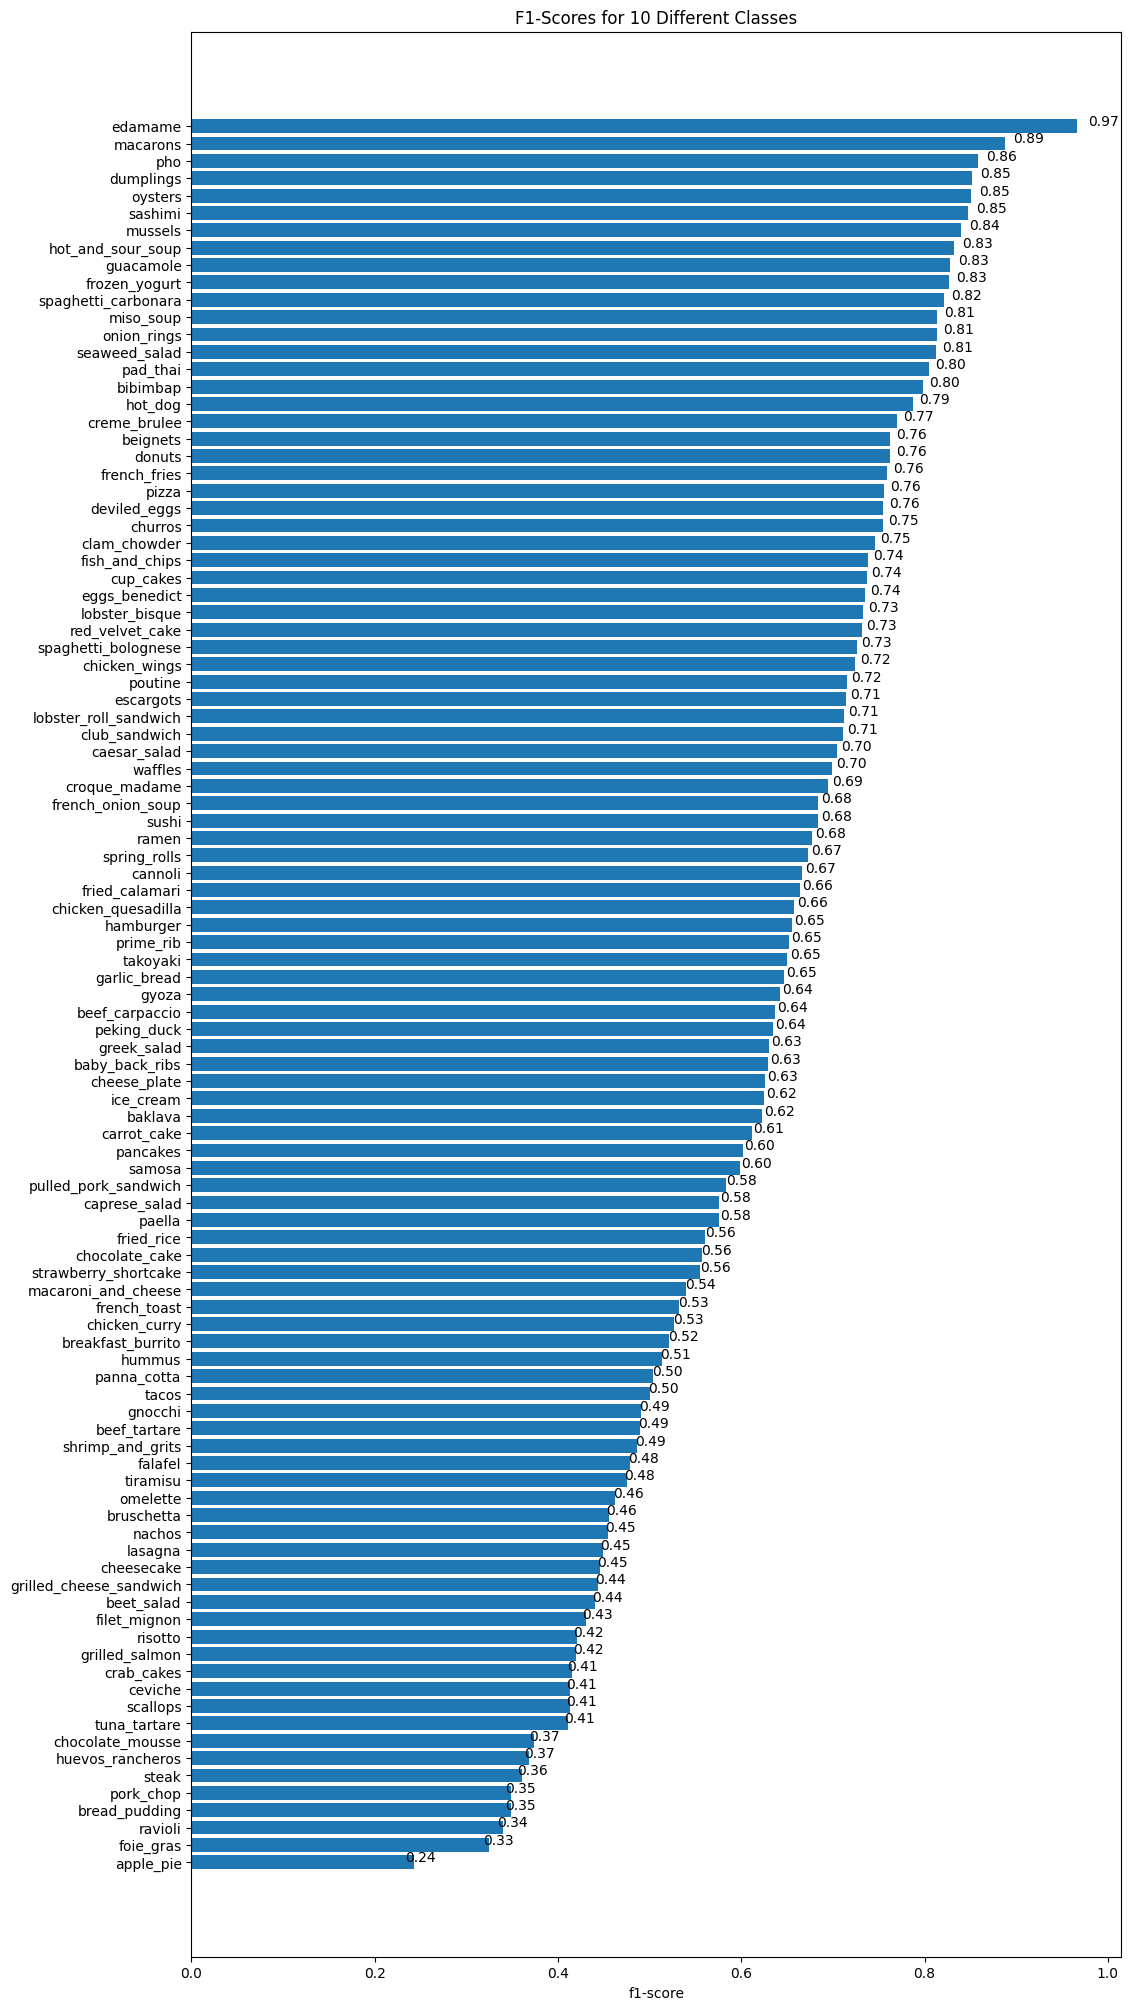

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 25))
scores = ax.barh(range(len(f1_scores)), f1_scores["f1-score"].values)
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(list(f1_scores["class_name"]))
ax.set_xlabel("f1-score")
ax.set_title("F1-Scores for 10 Different Classes")
ax.invert_yaxis(); # reverse the order

def autolabel(rects): # Modified version of: https://matplotlib.org/examples/api/barchart_demo.html
  """
  Attach a text label above each bar displaying its height (it's value).
  """
  for rect in rects:
    width = rect.get_width()
    ax.text(1.03*width, rect.get_y() + rect.get_height()/1.5,
            f"{width:.2f}",
            ha='center', va='bottom')

autolabel(scores)

In [46]:

def load_and_prep_image(filename, img_shape=224, scale=True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into
  (224, 224, 3).

  Parameters
  ----------
  filename (str): string filename of target image
  img_shape (int): size to resize target image to, default 224
  scale (bool): whether to scale pixel values to range(0, 1), default True
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.io.decode_image(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    # Rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


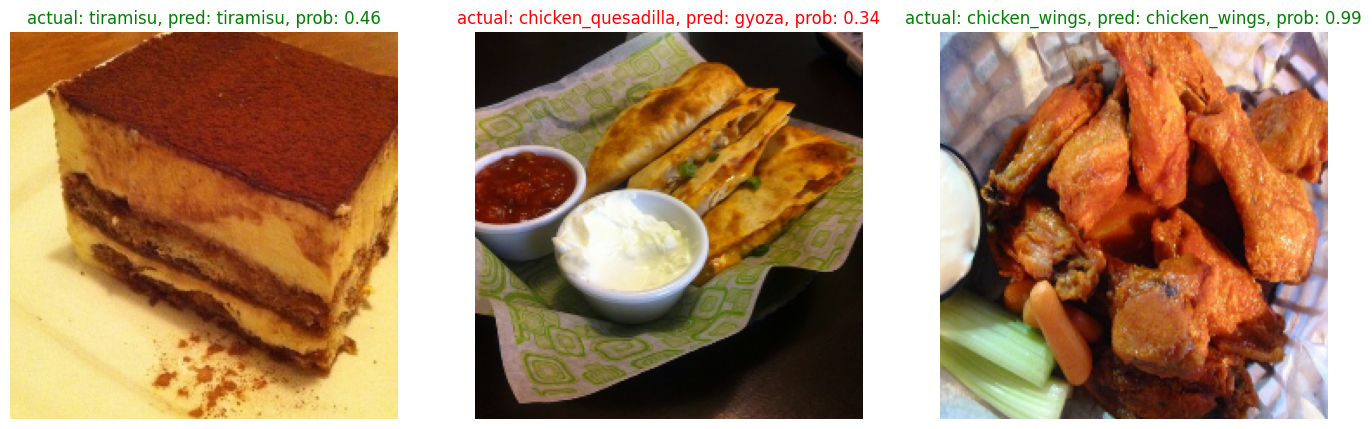

In [50]:
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf

test_dir = Path(test_dir)  # ensure it's a Path, in case it's still a string

plt.figure(figsize=(17, 10))
for i in range(3):
    # Choose a random image from a random class
    class_name = random.choice(class_names)
    class_path = test_dir / class_name                       # Path join
    filename = random.choice(os.listdir(class_path))         # os.listdir understands Path
    filepath = class_path / filename                         # full image path (Path)

    # Load the image and make predictions
    img = load_and_prep_image(str(filepath), scale=False)    # convert Path -> str for your loader
    pred_prob = model.predict(tf.expand_dims(img, axis=0))   # [1, 224, 224, 3]
    pred_class = class_names[pred_prob.argmax()]             # predicted class name

    # Plot the image(s)
    plt.subplot(1, 3, i + 1)
    plt.imshow(img / 255.0)
    title_color = "g" if class_name == pred_class else "r"
    plt.title(
        f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}",
        c=title_color,
    )
    plt.axis("off")

In [51]:
# 1. Get the filenames of all of our test data
filepaths = []
for filepath in test_data.list_files("101_food_classes_10_percent/test/*/*.jpg", 
                                     shuffle=False):
  filepaths.append(filepath.numpy())
filepaths[:10]
     

[b'101_food_classes_10_percent/test/apple_pie/1011328.jpg',
 b'101_food_classes_10_percent/test/apple_pie/101251.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1034399.jpg',
 b'101_food_classes_10_percent/test/apple_pie/103801.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1038694.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1047447.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1068632.jpg',
 b'101_food_classes_10_percent/test/apple_pie/110043.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1106961.jpg',
 b'101_food_classes_10_percent/test/apple_pie/1113017.jpg']

In [52]:
# 2. Create a dataframe out of current prediction data for analysis
import pandas as pd
pred_df = pd.DataFrame({"img_path": filepaths,
                        "y_true": y_labels,
                        "y_pred": pred_classes,
                        "pred_conf": pred_probs.max(axis=1), # get the maximum prediction probability value
                        "y_true_classname": [class_names[i] for i in y_labels],
                        "y_pred_classname": [class_names[i] for i in pred_classes]}) 
pred_df.head()
     

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.369123,apple_pie,apple_pie
1,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.808807,apple_pie,apple_pie
2,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.385175,apple_pie,apple_pie
3,b'101_food_classes_10_percent/test/apple_pie/1...,0,38,0.205556,apple_pie,fish_and_chips
4,b'101_food_classes_10_percent/test/apple_pie/1...,0,8,0.768597,apple_pie,bread_pudding


In [53]:
# 3. Is the prediction correct?
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.369123,apple_pie,apple_pie,True
1,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.808807,apple_pie,apple_pie,True
2,b'101_food_classes_10_percent/test/apple_pie/1...,0,0,0.385175,apple_pie,apple_pie,True
3,b'101_food_classes_10_percent/test/apple_pie/1...,0,38,0.205556,apple_pie,fish_and_chips,False
4,b'101_food_classes_10_percent/test/apple_pie/1...,0,8,0.768597,apple_pie,bread_pudding,False


In [54]:
# 4. Get the top 100 wrong examples
top_100_wrong = pred_df[pred_df["pred_correct"] == False].sort_values("pred_conf", ascending=False)[:100]
top_100_wrong.head(20)

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
23797,b'101_food_classes_10_percent/test/sushi/16593...,95,86,0.997969,sushi,sashimi,False
18001,b'101_food_classes_10_percent/test/pancakes/10...,72,67,0.995461,pancakes,omelette,False
191,b'101_food_classes_10_percent/test/apple_pie/3...,0,31,0.991456,apple_pie,donuts,False
22,b'101_food_classes_10_percent/test/apple_pie/1...,0,100,0.991321,apple_pie,waffles,False
11642,b'101_food_classes_10_percent/test/garlic_brea...,46,10,0.991137,garlic_bread,bruschetta,False
23631,b'101_food_classes_10_percent/test/strawberry_...,94,83,0.991063,strawberry_shortcake,red_velvet_cake,False
10847,b'101_food_classes_10_percent/test/fried_calam...,43,68,0.989603,fried_calamari,onion_rings,False
21810,b'101_food_classes_10_percent/test/scallops/17...,87,29,0.988766,scallops,cup_cakes,False
10013,b'101_food_classes_10_percent/test/french_frie...,40,43,0.985879,french_fries,fried_calamari,False
15359,b'101_food_classes_10_percent/test/lobster_rol...,61,53,0.984569,lobster_roll_sandwich,hamburger,False


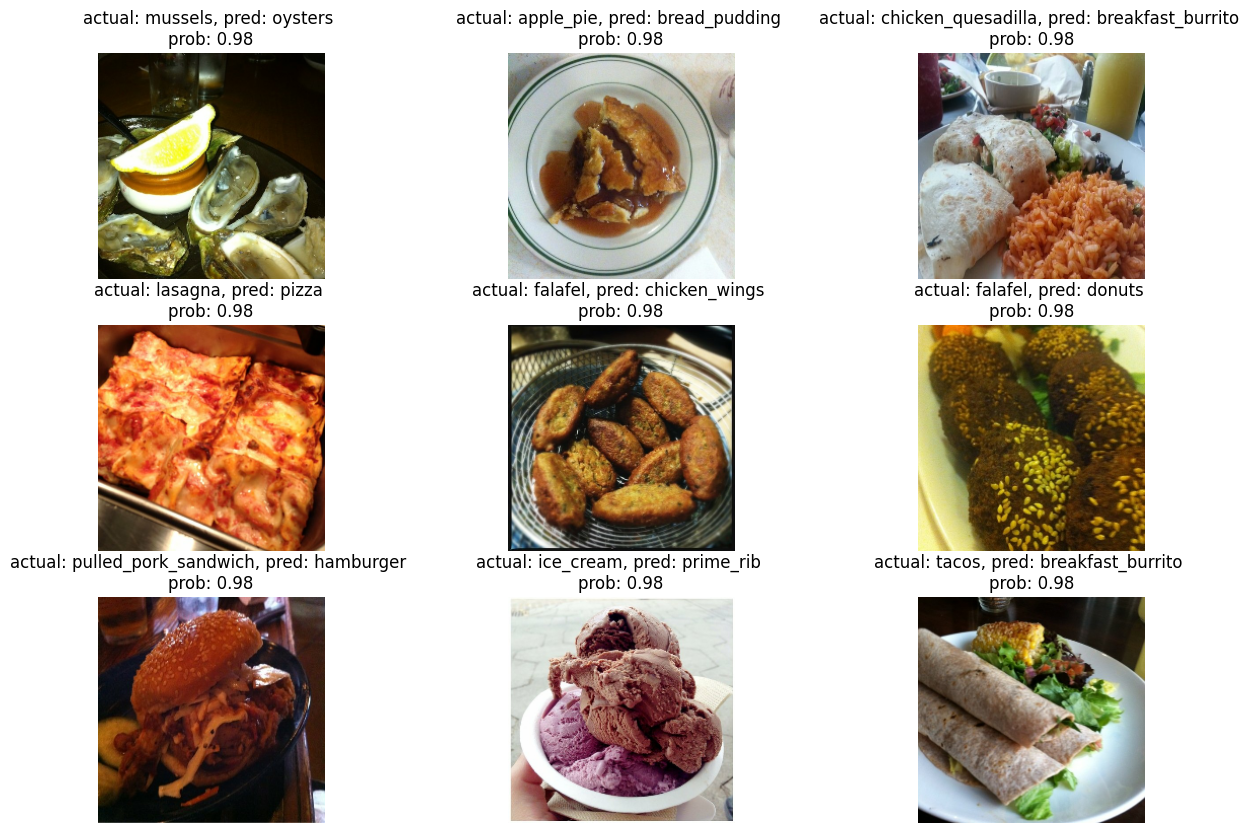

In [55]:

# 5. Visualize some of the most wrong examples
images_to_view = 9
start_index = 10 # change the start index to view more
plt.figure(figsize=(15, 10))
for i, row in enumerate(top_100_wrong[start_index:start_index+images_to_view].itertuples()): 
  plt.subplot(3, 3, i+1)
  img = load_and_prep_image(row[1], scale=True)
  _, _, _, _, pred_prob, y_true, y_pred, _ = row # only interested in a few parameters of each row
  plt.imshow(img)
  plt.title(f"actual: {y_true}, pred: {y_pred} \nprob: {pred_prob:.2f}")
  plt.axis(False)

In [56]:
from pathlib import Path

zip_path = Path("custom_food_images.zip")
data_dir = Path("custom_food_images")

if not zip_path.exists():
    !wget -O {zip_path} https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip
if not data_dir.exists():
    unzip_data(zip_path)

--2026-04-23 13:23:29--  https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.154.207, 142.251.110.207, 142.251.20.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.154.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13192985 (13M) [application/zip]
Saving to: ‘custom_food_images.zip’

custom_food_images. 100%[===================>]  12.58M  12.3MB/s    in 1.0s    

2026-04-23 13:23:30 (12.3 MB/s) - ‘custom_food_images.zip’ saved [13192985/13192985]



In [58]:
# Get custom food images filepaths
custom_food_images = ["custom_food_images/" + img_path for img_path in os.listdir("custom_food_images")]
custom_food_images

['custom_food_images/hamburger.jpeg',
 'custom_food_images/steak.jpeg',
 'custom_food_images/sushi.jpeg',
 'custom_food_images/chicken_wings.jpeg',
 'custom_food_images/ramen.jpeg',
 'custom_food_images/pizza-dad.jpeg']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


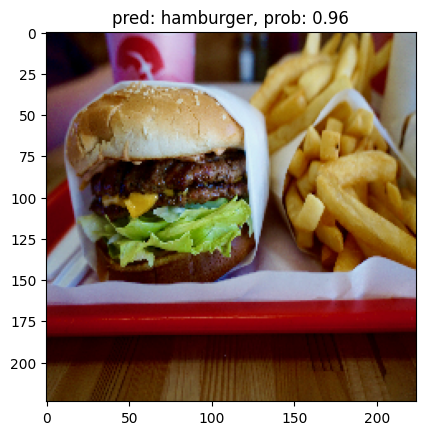

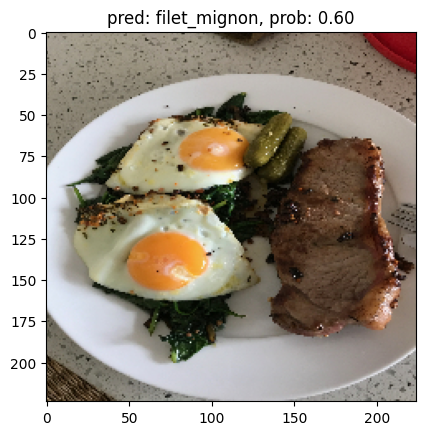

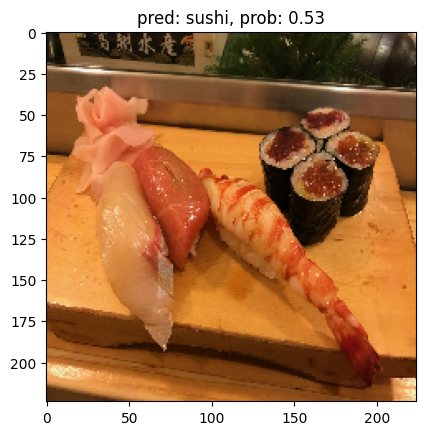

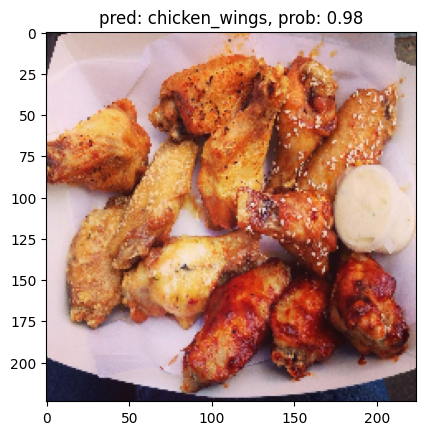

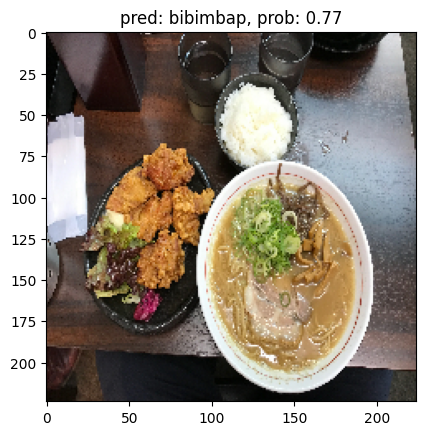

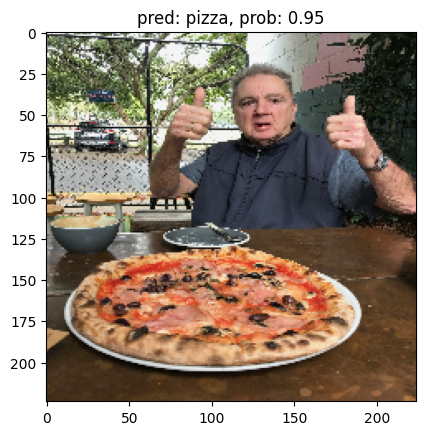

In [59]:
# Make predictions on custom food images
for img in custom_food_images:
  img = load_and_prep_image(img, scale=False) # load in target image and turn it into tensor
  pred_prob = model.predict(tf.expand_dims(img, axis=0)) # make prediction on image with shape [None, 224, 224, 3]
  pred_class = class_names[pred_prob.argmax()] # find the predicted class label
  # Plot the image with appropriate annotations
  plt.figure()
  plt.imshow(img/255.) # imshow() requires float inputs to be normalized
  plt.title(f"pred: {pred_class}, prob: {pred_prob.max():.2f}")